# 基于多种聚类算法实现鸢尾花聚类
## 1、用1个小例子来体验聚类

In [1]:
# 环境配置：中文字体显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import numpy as np
from sklearn.cluster import Birch # Birch聚类是一种层次聚类算法,导入模块

a = np.random.randint(0, 10, 3) # 0~10之间机选3个数
b = np.random.randint(20, 30, 3) # 20~30之间机选3个数
c = np.random.randint(40, 50, 3) # 40~50之间机选3个数
data = np.concatenate([a, b, c]) # 合并成一个数组
print(data) # 输出样本数据

# 创建Birch聚类模型，拟合数据
# 因为模型要求的样本数据是二维数组，所以reshape（变形）一下。
model = Birch().fit(data.reshape(-1, 1))

target = model.labels_ # labels_属性保存聚类结果（用数字表示每个样本的类别）
print(target) # 输出聚类结果

# 根据类别分别显示样本数据
k = target.max() + 1 # 得到类别的数量
print()
print('聚类结果:')
for i in range(k):
    print(data[target==i])


[ 9  3  3 23 28 25 42 45 42]
[0 0 0 1 1 1 2 2 2]

聚类结果:
[9 3 3]
[23 28 25]
[42 45 42]


## 2、K-均值聚类（K-Means）实现上面的例子

In [3]:
import numpy as np
from sklearn.cluster import KMeans # 引入K-Means聚类模型

a = np.random.randint(0, 10, 3) # 0~10之间机选3个数
b = np.random.randint(20, 30, 3) # 20~30之间机选3个数
c = np.random.randint(40, 50, 3) # 40~50之间机选3个数
data = np.concatenate([a, b, c]) # 合并成一个数组
print(data) # 输出样本数据

k = 3 # K-Means聚类需要事先指定聚类数量K
model = KMeans(n_clusters=k, n_init=10, random_state=0).fit(data.reshape(-1, 1))

target = model.labels_ # labels_属性保存聚类结果（用数字表示每个样本的类别）
print(target) # 输出聚类结果

# 根据类别分别显示样本数据
print()
print('聚类结果:')
for i in range(k):
    print(data[target==i])


[ 7  5  2 22 24 24 46 45 46]
[2 2 2 0 0 0 1 1 1]

聚类结果:
[22 24 24]
[46 45 46]
[7 5 2]


## 3、层次聚类Birch案例

### 3.1 生成数据

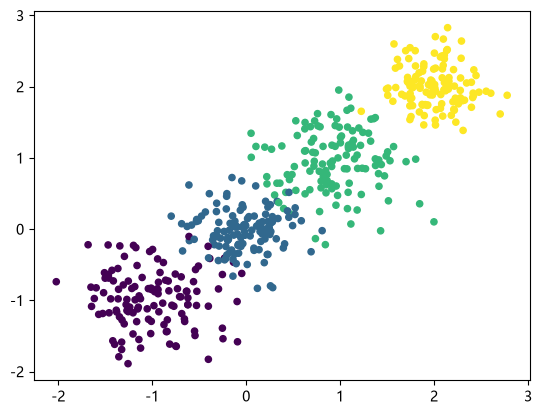

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs # 生成数据的模块

# 使用数据生成器随机生成500个样本，每个样本2个特征
# 共4个类簇，中心分别是[-1,-1], [0,0],[1,1], [2,2]
# 簇的标准差分别是[0.4, 0.3, 0.4, 0.3]（决定簇的离散程度）
X, y = make_blobs(n_samples=500, centers=[[-1,-1], [0,0], [1,1], [2,2]],
                  cluster_std=[0.4, 0.3, 0.4, 0.3], random_state=0)
# 画出散点图
plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
plt.show()


### 3.2 使用Birch算法进行聚类

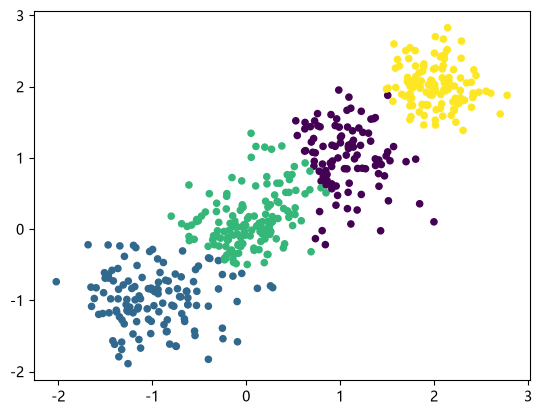

In [5]:
# Birch算法可以不指定聚类数量，也可以指定（参数为n_clusters）
# y_pred = Birch().fit_predict(X)
y_pred = Birch(n_clusters=4).fit_predict(X) # 指定聚类数量 4

plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=20)
plt.show()
# 不指定聚类数量时，模型将数据聚成了3类
# 指定聚类数量为4，模型能够将样本分开。


## 4、鸢尾花（iris）聚类实现

### 第1步、获得花瓣特征数据

In [6]:
from sklearn.datasets import load_iris # 鸢尾花数据集
from sklearn.cluster import KMeans, MeanShift, Birch, DBSCAN # 导入 KMeans, MeanShift, Birch, DBSCAN
from sklearn.metrics import adjusted_rand_score # 聚类模型评估工具
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

# 加载鸢尾花数（Iris）据集
iris = load_iris()
data = iris.data[:, 2:] # 取后两列（花瓣长、宽）作为特征数据
target = iris.target # 标签数据
feature_names = iris.feature_names[2:] # 后两列的名字
df = pd.DataFrame(data, columns=feature_names) # 创建数据框
display(df) # 显示数据集


,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


### 第2步、调用多种聚类算法，并评估成绩
#### 注意：聚类模型的评估使用sklearn.metrics.adjusted_rand_score函数
+ 参数1-实际类别标签
+ 参数2-聚类结果标签

In [7]:
# 调用聚类算法并拟合
model = KMeans(n_clusters=3, n_init=10, random_state=0).fit(data) # K-均值聚类
# model = MeanShift().fit(data) # 均值漂移聚类
# model = Birch().fit(data) # Birch聚类
c_target = model.labels_ # 聚类结果标签

# 使用adjusted_rand_score函数来评估聚类效果
# 参数1-实际类别标签
# 参数2-聚类结果标签
print('accuracy: ', adjusted_rand_score(target, c_target))


accuracy:  0.8856970310281228


### 第3步、使用Matplotlib将聚类结果与实际结果可视化

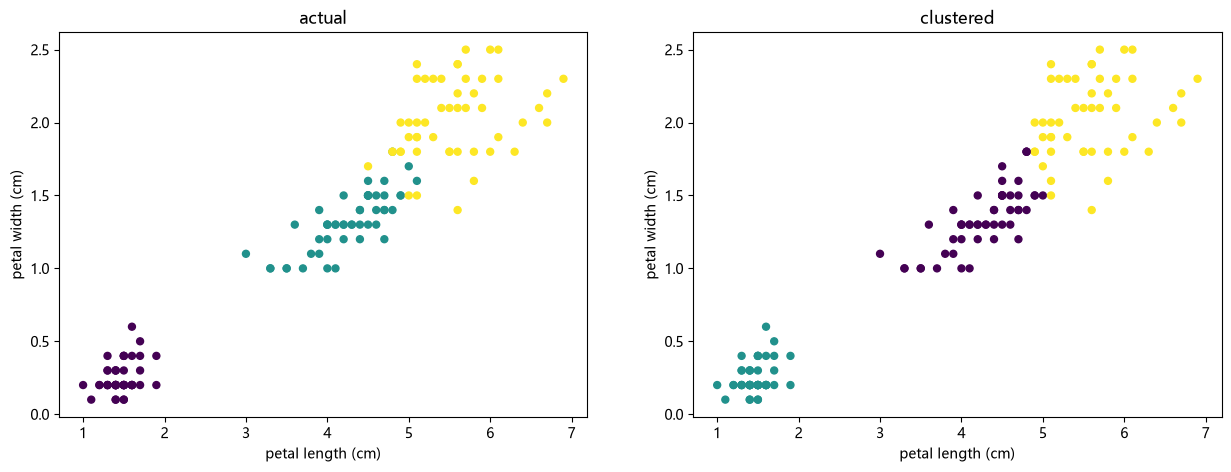

In [8]:
# 定义画板尺寸（15,5）
fig = plt.figure(figsize=(15,5))

# 画第一幅子图——实际类别标签
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(data[:, 0], data[:, 1], c=target, s=25)
ax1.set_title('actual')
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])

# 画第二幅子图——聚类结果
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(data[:, 0], data[:, 1], c=c_target, s=25)
ax2.set_title('clustered')
ax2.set_xlabel(feature_names[0])
ax2.set_ylabel(feature_names[1])

# 显示图形
plt.show()
